# Gender Classification (SVM Part)

In [1]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv('dataset/GENDER_CLASSIFICATION.csv')
df.head()

,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,feat_10,...,feat_24,feat_25,feat_26,feat_27,feat_28,feat_29,feat_30,feat_31,feat_32,gt
0,-0.900846,0.102587,-0.397814,0.112796,2.588096,-0.192754,-0.968311,-0.490886,-0.872099,-0.288411,...,2.541431,1.739102,0.166066,4.584869,-0.107031,-0.913990,-0.686416,-0.368085,-0.870545,0
1,-0.838868,0.039976,-0.387101,0.055413,2.066874,-0.226948,-0.947416,-0.472817,-0.855387,-0.207101,...,1.991721,1.259745,0.065058,3.019790,-0.110633,-0.890023,-0.611625,-0.298235,-0.855208,0
2,-0.814961,-0.010184,-0.397147,0.092713,1.897454,-0.269387,-0.945285,-0.449579,-0.849705,-0.151179,...,1.822978,1.105511,0.065353,2.500681,-0.052730,-0.885691,-0.583346,-0.218140,-0.856456,0
3,-0.110470,0.027849,-0.044310,-0.005343,0.177831,-0.232092,-0.562700,-0.400713,-0.552356,0.037349,...,-0.098367,-0.370318,-0.123008,-0.861314,0.106840,-0.483669,-0.224164,0.147321,-0.615051,0
4,-0.626313,-0.091985,-0.373756,-0.005083,1.172486,-0.314868,-0.885046,-0.412587,-0.818729,-0.012022,...,1.030348,0.421886,-0.068029,0.258984,-0.057158,-0.834079,-0.441066,-0.099874,-0.829539,0


In [5]:
df.shape

(1000, 33)

In [6]:
! pip install cvxopt

   ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.8 MB 991.0 kB/s eta 0:00:13
   ---------------------------------------- 0.1/12.8 MB 1.2 MB/s eta 0:00:11
    --------------------------------------- 0.2/12.8 MB 1.9 MB/s eta 0:00:07
   - -------------------------------------- 0.3/12.8 MB 1.9 MB/s eta 0:00:07
   - -------------------------------------- 0.5/12.8 MB 2.1 MB/s eta 0:00:07
   -- ------------------------------------- 0.7/12.8 MB 2.4 MB/s eta 0:00:06
   -- ------------------------------------- 0.8/12.8 MB 2.5 MB/s eta 0:00:05
   -- ------------------------------------- 0.9/12.8 MB 2.5 MB/s eta 0:00:05
   --- ------------------------------------ 1.0/12.8 MB 2.7 MB/s eta 0:00:05
   --- ------------------------------------ 1.2/12.8 MB 2.5 MB/s eta 0:00:05
   ---- ----------------------------------- 1.3/12.8 MB 2.6 MB/s eta 0:00:05
   ---- ----------------------------------- 1.4/12.8 MB 2.6 MB/s eta 0:00:05
   -

# Class svm

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from cvxopt import matrix, solvers

In [4]:
class MySVM:
    def __init__(self, C=1.0, kernel='Gaussian', gamma=None, p=3,
                 tol=1e-6):
        # hyperparams
        self.C = float(C)
        self.kernel_type = kernel 
        self.gamma = gamma    
        self.p = p
        self.tol = tol

        # learned attributes (popolati dopo fit)
        self.alphas = None        # all alpha (length n)
        self.support_ = None      # indices of support vectors
        self.X_sv = None
        self.y_sv = None
        self.alpha_sv = None      # alphas corresponding to sv
        self.b = 0.0

        # preprocessing
        self.scaler = None
        # mapping labels -> {-1, +1}
        self.label_map = None
        self.inv_label_map = None



    def kernel(self, X1, X2=None):
            if X2 is None:
                X2 = X1

            if self.kernel_type == "Gaussian":
                # Compute squared norms
                X1_sq = np.sum(X1**2, axis=1).reshape(-1, 1)
                X2_sq = np.sum(X2**2, axis=1).reshape(1, -1)
                # Pairwise squared distance
                dist_sq = X1_sq + X2_sq - 2 * X1 @ X2.T
                # RBF kernel
                K = np.exp(-self.gamma * dist_sq)
                return K

            elif self.kernel_type == "Polynomial":
                K = (X1 @ X2.T + 1 )**self.p
                return K
            

    def encode_labels(self, y):
        uniq = np.unique(y)
        if uniq.shape[0] != 2:
            raise ValueError("This implementation supports only binary classification.")
        # map unique[0] -> -1, unique[1] -> +1
        self.label_map = {uniq[0]: -1, uniq[1]: +1}
        self.inv_label_map = {-1: uniq[0], +1: uniq[1]}
        y_mapped = np.array([self.label_map[yy] for yy in y], dtype=float)
        return y_mapped
    
    
    def fit(self, X, y):
        """
        X: (n_samples, n_features) numpy array
        y: array-like labels (two classes)
        """
        X = np.asarray(X, dtype=float)
        y_in = np.asarray(y).ravel()

        # encode labels to -1 / +1
        y = self.encode_labels(y_in)

        # scaling
        self.scaler = StandardScaler().fit(X)
        Xs = self.scaler.transform(X)

        n_samples = Xs.shape[0]

        # compute full kernel matrix
        K = self.kernel(Xs)    # (n_samples, n_samples)

        # Build Q = (y y^T) * K
        Y = y.reshape(-1, 1)
        Q = (Y @ Y.T) * K  # elementwise multiply
        # numerical stabilizer: symmetrize & add tiny jitter
        # Q = 0.5 * (Q + Q.T) + 1e-12 * np.eye(n_samples)

        P = matrix(Q)                         # cvxopt matrix
        q = matrix(-np.ones((n_samples, 1)))  # minimize 1/2 a^T P a + q^T a -> q = -1

        # G and h for 0 <= alpha <= C
        G_std = np.vstack((-np.eye(n_samples), np.eye(n_samples)))
        h_std = np.hstack((np.zeros(n_samples), np.ones(n_samples) * self.C))
        G = matrix(G_std)
        h = matrix(h_std)

        # equality A y = 0  (sum alpha_i y_i = 0)
        A = matrix(y.reshape(1, -1))
        b = matrix(0.0)

        sol = solvers.qp(P, q, G, h, A, b)

        # extract alphas (as numpy array)
        alphas_all = np.array(sol['x']).reshape(-1)

                # keep full alphas array for diagnostics
        self.alphas = alphas_all.copy()

        # support vectors: alpha > tol
        sv_mask = alphas_all > self.tol
        sv_indices = np.where(sv_mask)[0]
        self.support_ = sv_indices
        self.X_sv = Xs[sv_mask]
        self.y_sv = y[sv_mask]
        self.alpha_sv = alphas_all[sv_mask]

        # compute bias b: average over alphas with 0 < alpha < C (free SV)
        free_sv_mask = (alphas_all > self.tol) & (alphas_all < self.C - self.tol)
        free_indices = np.where(free_sv_mask)[0]

        if free_indices.size > 0:
            b_vals = []
            for i in free_indices:
                # f(x_i) = sum_j alpha_j y_j K(x_j, x_i)
                f_i = np.sum(alphas_all * y * K[:, i])
                b_vals.append(y[i] - f_i)
            self.b = np.mean(b_vals)
        else:
            # fallback: average over all support vectors
            b_vals = []
            for idx in sv_indices:
                f_i = np.sum(alphas_all * y * K[:, idx])
                b_vals.append(y[idx] - f_i)
            self.b = np.mean(b_vals)

        # keep training-data-size alphas if needed (self.alphas already)
        return self
    

    def decision_function(self, X):
        """Return raw decision scores (float), using only SV."""
        X = np.asarray(X, dtype=float)
        Xs = self.scaler.transform(X)
        K = self.kernel(Xs, self.X_sv)  # shape (m, n_sv)
        # weights = alpha_sv * y_sv (elementwise)
        weights = self.alpha_sv * self.y_sv
        scores = K @ weights + self.b    # shape (m,)
        return np.asarray(scores).reshape(-1)

    def predict(self, X):
        scores = self.decision_function(X)
        preds = np.sign(scores)
        # map back to original labels
        return np.array([self.inv_label_map[int(p)] for p in preds])
    
    def score(self, X, y):
        y = np.asarray(y).ravel()  # <----- forza y a 1D
        y_pred = self.predict(X)
        return np.mean(y_pred == y)
    

    def get_support(self):
        return self.support_

In [5]:
def grid_search_cv(X, y, C_grid, gamma_grid=None, degree_grid=None,
                   k=5, random_state=0):
    """
    Grid search su Gaussian e Polynomial SVM con k-fold CV.
    """
    from sklearn.model_selection import StratifiedKFold

    y = np.asarray(y).ravel()  
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=random_state)

    best_score = -np.inf
    best_params = {}

    for C in C_grid:
        # --- Gaussian kernel ---
        if gamma_grid:
            for gamma in gamma_grid:
                scores = []
                for train_idx, val_idx in skf.split(X, y):
                    model = MySVM(C=C, kernel='Gaussian', gamma=gamma)
                    model.fit(X[train_idx], y[train_idx])
                    scores.append(model.score(X[val_idx], y[val_idx]))
                mean_score = np.mean(scores)
                if mean_score > best_score:
                    best_score = mean_score
                    best_params = {'C': C, 'gamma': gamma, 'kernel': 'Gaussian'}

        # --- Polynomial kernel ---
        if degree_grid:
            for degree in degree_grid:
                scores = []
                for train_idx, val_idx in skf.split(X, y):
                    model = MySVM(C=C, kernel='Polynomial', p=degree)
                    model.fit(X[train_idx], y[train_idx])
                    scores.append(model.score(X[val_idx], y[val_idx]))
                mean_score = np.mean(scores)
                if mean_score > best_score:
                    best_score = mean_score
                    best_params = {'C': C, 'degree': degree, 'kernel': 'Polynomial'}

    
    print(best_params, best_score)
    return best_params, best_score



gridsearch di prova

In [43]:
# Split features and target
X = df.drop("gt", axis=1).values
y = df["gt"].values.reshape(-1, 1)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2) grid search 
C_grid = [0.01, 0.1, 1, 10]
gamma_grid = [0.001, 0.01, 0.1, 1]
degree_grid = [2, 3, 4]
best_params, best_score = grid_search_cv(X_train, y_train, C_grid, gamma_grid=gamma_grid, degree_grid=degree_grid, k=5)

print("Best:", best_params, "score:", best_score)

# 3) final fit su tutto il dataset con iperparametri scelti
if best_params['kernel'] == 'Polynomial':
    model = MySVM(C=best_params['C'], kernel='Polynomial', p=best_params['degree'])
else:
    model = MySVM(C=best_params['C'], kernel=best_params['kernel'], gamma=best_params['gamma'])

model.fit(X_train, y_train)

# 4) test su nuovi dati
y_pred = model.predict(X_test)



     pcost       dcost       gap    pres   dres
 0: -9.2998e+01 -2.2526e+01  5e+03  7e+01  3e-15
 1: -1.3890e+01 -1.9389e+01  1e+02  2e+00  3e-15
 2: -5.1218e+00 -1.4225e+01  1e+01  7e-03  1e-15
 3: -5.4280e+00 -6.7557e+00  1e+00  1e-03  5e-16
 4: -5.7340e+00 -5.8523e+00  1e-01  8e-05  5e-16
 5: -5.7359e+00 -5.7818e+00  5e-02  3e-05  3e-16
 6: -5.7371e+00 -5.7828e+00  5e-02  3e-05  3e-16
 7: -5.7346e+00 -5.7744e+00  4e-02  1e-05  7e-16
 8: -5.7366e+00 -5.7716e+00  4e-02  8e-06  6e-16
 9: -5.7383e+00 -5.7682e+00  3e-02  6e-06  5e-16
10: -5.7399e+00 -5.7634e+00  2e-02  3e-06  4e-16
11: -5.7433e+00 -5.7574e+00  1e-02  3e-07  3e-16
12: -5.7472e+00 -5.7527e+00  6e-03  8e-08  5e-16
13: -5.7494e+00 -5.7503e+00  8e-04  2e-16  5e-16
14: -5.7498e+00 -5.7499e+00  1e-04  5e-17  5e-16
15: -5.7498e+00 -5.7498e+00  2e-06  2e-16  6e-16
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0: -1.0438e+02 -2.2765e+01  5e+03  7e+01  3e-15
 1: -1.3562e+01 -1.9999e+01  1e+02  2e+00  3e-1

In [45]:
X_pred = model.predict(X_train)

print(classification_report(y_train, X_pred))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95       404
           1       0.94      0.95      0.95       396

    accuracy                           0.95       800
   macro avg       0.95      0.95      0.95       800
weighted avg       0.95      0.95      0.95       800



In [46]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.89      0.92      0.90        96
           1       0.92      0.89      0.91       104

    accuracy                           0.91       200
   macro avg       0.90      0.91      0.90       200
weighted avg       0.91      0.91      0.91       200



In [9]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# Assumiamo che df sia già stato caricato e contenga la colonna "gt"

# Split features and target
X = df.drop("gt", axis=1).values
y = df["gt"].values.reshape(-1, 1)

# Split in train e test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 🔧 PARAMETRI MODIFICABILI
kernel_type = "poly"  # "rbf" per gaussiano, "poly" per polinomiale
C_param = 0.1        # parametro di regolarizzazione
gamma_param = 0  # 'scale', 'auto' o un valore float (usato solo in rbf o poly)
degree_param = 3     # usato solo se kernel == "poly"

# Creazione del modello SVM
svm_model = SVC(
    kernel=kernel_type,
    C=C_param,
    gamma='auto',
    degree=degree_param  # verrà ignorato se non è kernel "poly"
)

# Addestramento
svm_model.fit(X_train, y_train.ravel())

# Predizione
y_pred = svm_model.predict(X_test)

# Valutazione
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.88
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.98      0.89        96
           1       0.98      0.79      0.87       104

    accuracy                           0.88       200
   macro avg       0.89      0.88      0.88       200
weighted avg       0.90      0.88      0.88       200



use another type of fit, the smo algo to try it 

In [10]:
class MySVM_smo:
    def __init__(self, C=1.0, kernel='Gaussian', gamma=None, p=3,
                 tol=1e-6):
        # hyperparams
        self.C = float(C)
        self.kernel_type = kernel 
        self.gamma = gamma    
        self.p = p
        self.tol = tol

        # learned attributes (popolati dopo fit)
        self.alphas = None        # all alpha (length n)
        self.support_ = None      # indices of support vectors
        self.X_sv = None
        self.y_sv = None
        self.alpha_sv = None      # alphas corresponding to sv
        self.b = 0.0

        # preprocessing
        self.scaler = None
        # mapping labels -> {-1, +1}
        self.label_map = None
        self.inv_label_map = None



    def kernel(self, X1, X2=None):
            if X2 is None:
                X2 = X1

            if self.kernel_type == "Gaussian":
                # Compute squared norms
                X1_sq = np.sum(X1**2, axis=1).reshape(-1, 1)
                X2_sq = np.sum(X2**2, axis=1).reshape(1, -1)
                # Pairwise squared distance
                dist_sq = X1_sq + X2_sq - 2 * X1 @ X2.T
                # RBF kernel
                K = np.exp(-self.gamma * dist_sq)
                return K

            elif self.kernel_type == "Polynomial":
                K = (X1 @ X2.T + 1 )**self.p
                return K
            

    def encode_labels(self, y):
        uniq = np.unique(y)
        if uniq.shape[0] != 2:
            raise ValueError("This implementation supports only binary classification.")
        # map unique[0] -> -1, unique[1] -> +1
        self.label_map = {uniq[0]: -1, uniq[1]: +1}
        self.inv_label_map = {-1: uniq[0], +1: uniq[1]}
        y_mapped = np.array([self.label_map[yy] for yy in y], dtype=float)
        return y_mapped
    
    
    def fit_smo(self, X, y, max_passes=5):
        """
        Simplified SMO training for SVM (binary classification).
        Replaces QP solver with Platt's SMO algorithm.
        Works with Gaussian/Polynomial kernel defined in self.kernel().
        
        Parameters
        ----------
        X : array-like, shape (n_samples, n_features)
        y : array-like, shape (n_samples,)
        max_passes : int, stopping criterion (number of passes with no alpha change)
        """
        X = np.asarray(X, dtype=float)
        y_in = np.asarray(y).ravel()

        # encode labels
        y = self.encode_labels(y_in)

        # scale
        self.scaler = StandardScaler().fit(X)
        Xs = self.scaler.transform(X)

        n_samples = Xs.shape[0]
        alphas = np.zeros(n_samples)
        b = 0.0

        # kernel matrix
        K = self.kernel(Xs)

        passes = 0
        while passes < max_passes:
            num_changed = 0
            for i in range(n_samples):
                # prediction for x_i
                f_i = np.sum(alphas * y * K[:, i]) + b
                E_i = f_i - y[i]

                if ((y[i]*E_i < -self.tol and alphas[i] < self.C) or
                    (y[i]*E_i > self.tol and alphas[i] > 0)):
                    # choose j != i randomly
                    j = np.random.choice([jj for jj in range(n_samples) if jj != i])
                    f_j = np.sum(alphas * y * K[:, j]) + b
                    E_j = f_j - y[j]

                    alpha_i_old, alpha_j_old = alphas[i], alphas[j]

                    # compute L, H
                    if y[i] != y[j]:
                        L = max(0, alphas[j] - alphas[i])
                        H = min(self.C, self.C + alphas[j] - alphas[i])
                    else:
                        L = max(0, alphas[i] + alphas[j] - self.C)
                        H = min(self.C, alphas[i] + alphas[j])
                    if L == H:
                        continue

                    # eta (second derivative)
                    eta = 2 * K[i, j] - K[i, i] - K[j, j]
                    if eta >= 0:
                        continue

                    # update alpha_j
                    alphas[j] -= y[j] * (E_i - E_j) / eta
                    # clip
                    alphas[j] = np.clip(alphas[j], L, H)

                    if abs(alphas[j] - alpha_j_old) < 1e-5:
                        continue

                    # update alpha_i
                    alphas[i] += y[i] * y[j] * (alpha_j_old - alphas[j])

                    # compute bias terms
                    b1 = b - E_i - y[i]*(alphas[i]-alpha_i_old)*K[i, i] - \
                        y[j]*(alphas[j]-alpha_j_old)*K[i, j]
                    b2 = b - E_j - y[i]*(alphas[i]-alpha_i_old)*K[i, j] - \
                        y[j]*(alphas[j]-alpha_j_old)*K[j, j]

                    if 0 < alphas[i] < self.C:
                        b = b1
                    elif 0 < alphas[j] < self.C:
                        b = b2
                    else:
                        b = 0.5*(b1 + b2)

                    num_changed += 1

            if num_changed == 0:
                passes += 1
            else:
                passes = 0

        # save results
        self.alphas = alphas
        self.b = b

        sv_mask = alphas > self.tol
        self.support_ = np.where(sv_mask)[0]
        self.X_sv = Xs[sv_mask]
        self.y_sv = y[sv_mask]
        self.alpha_sv = alphas[sv_mask]

        return self
    

    def decision_function(self, X):
        """Return raw decision scores (float), using only SV."""
        X = np.asarray(X, dtype=float)
        Xs = self.scaler.transform(X)
        K = self.kernel(Xs, self.X_sv)  # shape (m, n_sv)
        # weights = alpha_sv * y_sv (elementwise)
        weights = self.alpha_sv * self.y_sv
        scores = K @ weights + self.b    # shape (m,)
        return np.asarray(scores).reshape(-1)

    def predict(self, X):
        scores = self.decision_function(X)
        preds = np.sign(scores)
        # map back to original labels
        return np.array([self.inv_label_map[int(p)] for p in preds])
    
    def score(self, X, y):
        y = np.asarray(y).ravel()  # <----- forza y a 1D
        y_pred = self.predict(X)
        return np.mean(y_pred == y)
    

    def get_support(self):
        return self.support_

In [15]:
def grid_search_cv_smo(X, y, C_grid, gamma_grid=None, degree_grid=None,
                   k=5, random_state=0):
    """
    Grid search su Gaussian e Polynomial SVM con k-fold CV.
    """
    from sklearn.model_selection import StratifiedKFold

    y = np.asarray(y).ravel()  
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=random_state)

    best_score = -np.inf
    best_params = {}

    for C in C_grid:
        # --- Gaussian kernel ---
        if gamma_grid:
            for gamma in gamma_grid:
                scores = []
                for train_idx, val_idx in skf.split(X, y):
                    model = MySVM_smo(C=C, kernel='Gaussian', gamma=gamma)
                    model.fit_smo(X[train_idx], y[train_idx])
                    scores.append(model.score(X[val_idx], y[val_idx]))
                mean_score = np.mean(scores)
                print(f"Trying C={C}, gamma={gamma} -> mean score={mean_score:.4f}")
                if mean_score > best_score:
                    best_score = mean_score
                    best_params = {'C': C, 'gamma': gamma, 'kernel': 'Gaussian'}

        # --- Polynomial kernel ---
        if degree_grid:
            for degree in degree_grid:
                scores = []
                for train_idx, val_idx in skf.split(X, y):
                    model = MySVM_smo(C=C, kernel='Polynomial', p=degree)
                    model.fit_smo(X[train_idx], y[train_idx])
                    scores.append(model.score(X[val_idx], y[val_idx]))
                mean_score = np.mean(scores)
                print(f"Trying C={C}, degree={degree} -> mean score={mean_score:.4f}")

                if mean_score > best_score:
                    best_score = mean_score
                    best_params = {'C': C, 'degree': degree, 'kernel': 'Polynomial'}

    
    print(best_params, best_score)
    return best_params, best_score



In [16]:
# Split features and target
X = df.drop("gt", axis=1).values
y = df["gt"].values.reshape(-1, 1)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2) grid search 
C_grid = [0.01, 0.1, 1]
gamma_grid = [0.01, 0.1, 1]
degree_grid = [2, 3, 4]
best_params, best_score = grid_search_cv_smo(X_train, y_train, C_grid, gamma_grid=gamma_grid, degree_grid=degree_grid, k=5)

print("Best:", best_params, "score:", best_score)

# 3) final fit su tutto il dataset con iperparametri scelti
if best_params['kernel'] == 'Polynomial':
    model = MySVM_smo(C=best_params['C'], kernel='Polynomial', p=best_params['degree'])
else:
    model = MySVM_smo(C=best_params['C'], kernel=best_params['kernel'], gamma=best_params['gamma'])

model.fit(X_train, y_train)

# 4) test su nuovi dati
y_pred = model.predict(X_test)



Trying C=0.01, gamma=0.01 -> mean score=0.9137
Trying C=0.01, gamma=0.1 -> mean score=0.9100
Trying C=0.01, gamma=1 -> mean score=0.5025
Trying C=0.01, degree=2 -> mean score=0.9175
Trying C=0.01, degree=3 -> mean score=0.8912


KeyboardInterrupt: 

# Second part

In [12]:
class SVM_2:
    def __init__(self, C=1.0, kernel='Gaussian', gamma=1, p=3,
                 tol=1e-6):
        # hyperparams
        self.C = float(C)
        self.kernel_type = kernel 
        self.gamma = gamma    
        self.p = p
        self.tol = tol

        # learned attributes
        self.alphas = None        # all alpha (length n)
        self.support_ = None      # indices of support vectors
        self.X_sv = None
        self.y_sv = None
        self.alpha_sv = None      # alphas corresponding to sv
        self.b = 0.0

        # preprocessing
        self.scaler = None
        # mapping labels -> {-1, +1}
        self.label_map = None
        self.inv_label_map = None



    def kernel(self, X1, X2=None):
            if X2 is None:
                X2 = X1

            if self.kernel_type == "Gaussian":
                # Compute squared norms
                X1_sq = np.sum(X1**2, axis=1).reshape(-1, 1)
                X2_sq = np.sum(X2**2, axis=1).reshape(1, -1)
                # Pairwise squared distance
                dist_sq = X1_sq + X2_sq - 2 * X1 @ X2.T
                # RBF kernel
                K = np.exp(-self.gamma * dist_sq)
                return K

            elif self.kernel_type == "Polynomial":
                K = (X1 @ X2.T + 1)**self.p
                return K
            

    def encode_labels(self, y):
        uniq = np.unique(y)
        if uniq.shape[0] != 2:
            raise ValueError("This implementation supports only binary classification.")
        # map unique[0] -> -1, unique[1] -> +1
        self.label_map = {uniq[0]: -1, uniq[1]: +1}
        self.inv_label_map = {-1: uniq[0], +1: uniq[1]}
        y_mapped = np.array([self.label_map[yy] for yy in y], dtype=float)
        return y_mapped
    
    
    def fit(self, X, y):
        """
        X: (n_samples, n_features) numpy array
        y: array-like labels (two classes)
        """
        X = np.asarray(X, dtype=float)
        y_in = np.asarray(y).ravel()

        # encode labels to -1 / +1
        y = self.encode_labels(y_in)

        # scaling
        self.scaler = StandardScaler().fit(X)
        Xs = self.scaler.transform(X)

        n_samples = Xs.shape[0]

        # compute full kernel matrix
        K = self.kernel(Xs)    # (n_samples, n_samples)

        # Build Q = (y y^T) * K
        Y = y.reshape(-1, 1)
        Q = (Y @ Y.T) * K  # elementwise multiply
        # numerical stabilizer: symmetrize & add tiny jitter
        # Q = 0.5 * (Q + Q.T) + 1e-12 * np.eye(n_samples)

        P = matrix(Q)                         # cvxopt matrix
        q = matrix(-np.ones((n_samples, 1)))  # minimize 1/2 a^T P a + q^T a -> q = -1

        # G and h for 0 <= alpha <= C
        G_std = np.vstack((-np.eye(n_samples), np.eye(n_samples)))
        h_std = np.hstack((np.zeros(n_samples), np.ones(n_samples) * self.C))
        G = matrix(G_std)
        h = matrix(h_std)

        # equality A y = 0  (sum alpha_i y_i = 0)
        A = matrix(y.reshape(1, -1))
        b = matrix(0.0)

        sol = solvers.qp(P, q, G, h, A, b)

        # extract alphas (as numpy array)
        alphas_all = np.array(sol['x']).reshape(-1)

        # keep full alphas array for diagnostics
        self.alphas = alphas_all.copy()

        # support vectors: alpha > tol
        sv_mask = alphas_all > self.tol
        sv_indices = np.where(sv_mask)[0]
        self.support_ = sv_indices
        self.X_sv = Xs[sv_mask]
        self.y_sv = y[sv_mask]
        self.alpha_sv = alphas_all[sv_mask]

        # compute bias b: average over alphas with 0 < alpha < C (free SV)
        free_sv_mask = (alphas_all > self.tol) & (alphas_all < self.C - self.tol)
        free_indices = np.where(free_sv_mask)[0]

        if free_indices.size > 0:
            b_vals = []
            for i in free_indices:
                # f(x_i) = sum_j alpha_j y_j K(x_j, x_i)
                f_i = np.sum(alphas_all * y * K[:, i])
                b_vals.append(y[i] - f_i)
            self.b = np.mean(b_vals)
        else:
            # fallback: average over all support vectors
            b_vals = []
            for idx in sv_indices:
                f_i = np.sum(alphas_all * y * K[:, idx])
                b_vals.append(y[idx] - f_i)
            self.b = np.mean(b_vals)

        # keep training-data-size alphas if needed (self.alphas already)
        return self
    

    def decision_function(self, X):
        """Return raw decision scores (float), using only SV."""
        X = np.asarray(X, dtype=float)
        Xs = self.scaler.transform(X)
        K = self.kernel(Xs, self.X_sv)  # shape (m, n_sv)
        # weights = alpha_sv * y_sv (elementwise)
        weights = self.alpha_sv * self.y_sv
        scores = K @ weights + self.b    # shape (m,)
        return np.asarray(scores).reshape(-1)

    def predict(self, X):
        scores = self.decision_function(X)
        preds = np.where(scores >= 0, 1, -1)
        # map back to original labels
        return np.array([self.inv_label_map[int(p)] for p in preds])
    
    def score(self, X, y):
        y = np.asarray(y)
        y_pred = self.predict(X)
        return np.mean(y_pred == y)
    

    def get_support(self):
        return self.support_
    
    def fit_smo(self, X, y, tol=1e-3, max_passes=10, max_iter=10):

        X = np.asarray(X, dtype=float)
        y_in = np.asarray(y).ravel()
        y_enc = self.encode_labels(y_in)
        self.scaler = StandardScaler().fit(X)
        Xs = self.scaler.transform(X)
        n = y_enc.shape[0]
        alphas = np.zeros(n)
        b = 0.0
        passes = 0
        iteration = 0
        K = self.kernel(Xs)

        def f(i):
            return np.sum(alphas * y_enc * K[:, i]) + b

        E = np.array([f(i) - y_enc[i] for i in range(n)])

        while passes < max_passes and iteration < max_iter:
            print(f"\n--- Iteration {iteration + 1}, consecutive passes without updates: {passes} ---")
            num_changed = 0
            tested_pairs = set()

            for i in range(n):
                ei = E[i]
                ai = alphas[i]
                yi = y_enc[i]

                kkt_violation = ((ai < self.C and yi * ei < -tol) or (ai > 0 and yi * ei > tol))

                if not kkt_violation:
                    continue

                candidates = [k for k in range(n) if k != i and abs(E[k] - ei) > 1e-3]
                if not candidates:
                    continue

                j = np.argmax(np.abs(E[candidates] - ei))

                if (i, j) in tested_pairs:
                    continue
                tested_pairs.add((i, j))

                aj = alphas[j]
                yj = y_enc[j]
                ej = E[j]

                if yi != yj:
                    L = max(0, aj - ai)
                    H = min(self.C, self.C + aj - ai)
                else:
                    L = max(0, ai + aj - self.C)
                    H = min(self.C, ai + aj)

                if L == H:
                    continue

                eta = 2 * K[i, j] - K[i, i] - K[j, j]
                if eta >= 0:
                    continue

                old_aj = aj
                alphas[j] -= yj * (ei - ej) / eta
                alphas[j] = np.clip(alphas[j], L, H)

                if abs(alphas[j] - old_aj) < 1e-5:
                    continue

                alphas[i] += yi * yj * (old_aj - alphas[j])

                b1 = b - ei - yi * (alphas[i] - ai) * K[i, i] - yj * (alphas[j] - old_aj) * K[i, j]
                b2 = b - ej - yi * (alphas[i] - ai) * K[i, j] - yj * (alphas[j] - old_aj) * K[j, j]

                if 0 < alphas[i] < self.C:
                    b = b1
                elif 0 < alphas[j] < self.C:
                    b = b2
                else:
                    b = (b1 + b2) / 2

                E = np.array([f(k) - y_enc[k] for k in range(n)])
                num_changed += 1

            print(f"Number of alphas updated in this iteration: {num_changed}")

            if num_changed == 0:
                passes += 1
            else:
                passes = 0

            iteration += 1

        # Store final model
        sv_mask = alphas > 1e-6
        self.alpha_sv = alphas[sv_mask]
        self.b = b
        self.X_sv = Xs[sv_mask]
        self.y_sv = y_enc[sv_mask]


        print(f"\nTraining completed in {iteration} iterations. Total support vectors: {len(self.alpha_sv)}")
        return self



In [18]:
class SVM_2:
    def __init__(self, C=1.0, kernel='Gaussian', gamma=1, p=3,
                 tol=1e-6):
        # hyperparams
        self.C = float(C)
        self.kernel_type = kernel 
        self.gamma = gamma    
        self.p = p
        self.tol = tol

        # learned attributes
        self.alphas = None        # all alpha (length n)
        self.support_ = None      # indices of support vectors
        self.X_sv = None
        self.y_sv = None
        self.alpha_sv = None      # alphas corresponding to sv
        self.b = 0.0

        # preprocessing
        self.scaler = None
        # mapping labels -> {-1, +1}
        self.label_map = None
        self.inv_label_map = None



    def kernel(self, X1, X2=None):
            if X2 is None:
                X2 = X1

            if self.kernel_type == "Gaussian":
                # Compute squared norms
                X1_sq = np.sum(X1**2, axis=1).reshape(-1, 1)
                X2_sq = np.sum(X2**2, axis=1).reshape(1, -1)
                # Pairwise squared distance
                dist_sq = X1_sq + X2_sq - 2 * X1 @ X2.T
                # RBF kernel
                K = np.exp(-self.gamma * dist_sq)
                return K

            elif self.kernel_type == "Polynomial":
                K = (X1 @ X2.T + 1)**self.p
                return K
            

    def encode_labels(self, y):
        uniq = np.unique(y)
        if uniq.shape[0] != 2:
            raise ValueError("This implementation supports only binary classification.")
        # map unique[0] -> -1, unique[1] -> +1
        self.label_map = {uniq[0]: -1, uniq[1]: +1}
        self.inv_label_map = {-1: uniq[0], +1: uniq[1]}
        y_mapped = np.array([self.label_map[yy] for yy in y], dtype=float)
        return y_mapped
    
    
    def fit(self, X, y):
        """
        X: (n_samples, n_features) numpy array
        y: array-like labels (two classes)
        """
        X = np.asarray(X, dtype=float)
        y_in = np.asarray(y).ravel()

        # encode labels to -1 / +1
        y = self.encode_labels(y_in)

        # scaling
        self.scaler = StandardScaler().fit(X)
        Xs = self.scaler.transform(X)

        n_samples = Xs.shape[0]

        # compute full kernel matrix
        K = self.kernel(Xs)    # (n_samples, n_samples)

        # Build Q = (y y^T) * K
        Y = y.reshape(-1, 1)
        Q = (Y @ Y.T) * K  # elementwise multiply
        # numerical stabilizer: symmetrize & add tiny jitter
        # Q = 0.5 * (Q + Q.T) + 1e-12 * np.eye(n_samples)

        P = matrix(Q)                         # cvxopt matrix
        q = matrix(-np.ones((n_samples, 1)))  # minimize 1/2 a^T P a + q^T a -> q = -1

        # G and h for 0 <= alpha <= C
        G_std = np.vstack((-np.eye(n_samples), np.eye(n_samples)))
        h_std = np.hstack((np.zeros(n_samples), np.ones(n_samples) * self.C))
        G = matrix(G_std)
        h = matrix(h_std)

        # equality A y = 0  (sum alpha_i y_i = 0)
        A = matrix(y.reshape(1, -1))
        b = matrix(0.0)

        sol = solvers.qp(P, q, G, h, A, b)

        # extract alphas (as numpy array)
        alphas_all = np.array(sol['x']).reshape(-1)

        # keep full alphas array for diagnostics
        self.alphas = alphas_all.copy()

        # support vectors: alpha > tol
        sv_mask = alphas_all > self.tol
        sv_indices = np.where(sv_mask)[0]
        self.support_ = sv_indices
        self.X_sv = Xs[sv_mask]
        self.y_sv = y[sv_mask]
        self.alpha_sv = alphas_all[sv_mask]

        # compute bias b: average over alphas with 0 < alpha < C (free SV)
        free_sv_mask = (alphas_all > self.tol) & (alphas_all < self.C - self.tol)
        free_indices = np.where(free_sv_mask)[0]

        if free_indices.size > 0:
            b_vals = []
            for i in free_indices:
                # f(x_i) = sum_j alpha_j y_j K(x_j, x_i)
                f_i = np.sum(alphas_all * y * K[:, i])
                b_vals.append(y[i] - f_i)
            self.b = np.mean(b_vals)
        else:
            # fallback: average over all support vectors
            b_vals = []
            for idx in sv_indices:
                f_i = np.sum(alphas_all * y * K[:, idx])
                b_vals.append(y[idx] - f_i)
            self.b = np.mean(b_vals)

        # keep training-data-size alphas if needed (self.alphas already)
        return self
    

    def decision_function(self, X):
        """Return raw decision scores (float), using only SV."""
        X = np.asarray(X, dtype=float)
        Xs = self.scaler.transform(X)
        K = self.kernel(Xs, self.X_sv)  # shape (m, n_sv)
        # weights = alpha_sv * y_sv (elementwise)
        weights = self.alpha_sv * self.y_sv
        scores = K @ weights + self.b    # shape (m,)
        return np.asarray(scores).reshape(-1)

    def predict(self, X):
        scores = self.decision_function(X)
        preds = np.where(scores >= 0, 1, -1)
        # map back to original labels
        return np.array([self.inv_label_map[int(p)] for p in preds])
    
    def score(self, X, y):
        y = np.asarray(y)
        y_pred = self.predict(X)
        return np.mean(y_pred == y)
    

    def get_support(self):
        return self.support_

    def fit_smo(self, X, y, tol=1e-3, max_passes=10, max_iter=10):
        X = np.asarray(X, dtype=float)
        y_in = np.asarray(y).ravel()
        y_enc = self.encode_labels(y_in)
        self.scaler = StandardScaler().fit(X)
        Xs = self.scaler.transform(X)
        n = y_enc.shape[0]
        alphas = np.zeros(n)
        b = 0.0
        passes = 0
        iteration = 0
        K = self.kernel(Xs)

        def f(i):
            return np.sum(alphas * y_enc * K[:, i]) + b

        # Inizializza E in modo incrementale
        E = np.array([f(i) - y_enc[i] for i in range(n)])

        while passes < max_passes and iteration < max_iter:
            print(f"\n--- Iteration {iteration + 1}, consecutive passes without updates: {passes} ---")
            num_changed = 0
            tested_pairs = np.zeros((n, n), dtype=bool)  # Uso di una matrice booleana per il controllo

            for i in range(n):
                ei = E[i]
                ai = alphas[i]
                yi = y_enc[i]

                # Controllo KKT
                kkt_violation = ((ai < self.C and yi * ei < -tol) or (ai > 0 and yi * ei > tol))
                if not kkt_violation:
                    continue

                # Seleziona il secondo esempio in modo più efficiente
                candidates = np.where(np.abs(E - ei) > 1e-3)[0]  # Seleziona solo quelli con errore significativo
                candidates = candidates[candidates != i]  # Escludi il punto corrente

                if len(candidates) == 0:
                    continue

                j = np.argmax(np.abs(E[candidates] - ei))  # Seleziona il punto con l'errore maggiore

                # Se la coppia è già stata testata, salta
                if tested_pairs[i, j]:
                    continue
                tested_pairs[i, j] = True
                tested_pairs[j, i] = True  # Per evitare di testare di nuovo la stessa coppia (simmetria)

                aj = alphas[j]
                yj = y_enc[j]
                ej = E[j]

                # Calcola i limiti L e H
                if yi != yj:
                    L = max(0, aj - ai)
                    H = min(self.C, self.C + aj - ai)
                else:
                    L = max(0, ai + aj - self.C)
                    H = min(self.C, ai + aj)

                if L == H:
                    continue

                eta = 2 * K[i, j] - K[i, i] - K[j, j]
                if eta >= 0:
                    continue

                old_aj = aj
                alphas[j] -= yj * (ei - ej) / eta
                alphas[j] = np.clip(alphas[j], L, H)

                if abs(alphas[j] - old_aj) < 1e-5:
                    continue

                alphas[i] += yi * yj * (old_aj - alphas[j])

                # Aggiorna il bias b
                b1 = b - ei - yi * (alphas[i] - ai) * K[i, i] - yj * (alphas[j] - old_aj) * K[i, j]
                b2 = b - ej - yi * (alphas[i] - ai) * K[i, j] - yj * (alphas[j] - old_aj) * K[j, j]

                if 0 < alphas[i] < self.C:
                    b = b1
                elif 0 < alphas[j] < self.C:
                    b = b2
                else:
                    b = (b1 + b2) / 2

                # Aggiorna l'errore
                E = np.array([f(k) - y_enc[k] for k in range(n)])
                num_changed += 1

            print(f"Number of alphas updated in this iteration: {num_changed}")

            if num_changed == 0:
                passes += 1
            else:
                passes = 0

            iteration += 1

        # Salva il modello finale
        sv_mask = alphas > 1e-6
        self.alpha_sv = alphas[sv_mask]
        self.b = b
        self.X_sv = Xs[sv_mask]
        self.y_sv = y_enc[sv_mask]

        print(f"\nTraining completed in {iteration} iterations. Total support vectors: {len(self.alpha_sv)}")
        return self


In [19]:
from sklearn.model_selection import train_test_split

# ----- 1. Estrai X e y dal DataFrame -----
# Sostituisci questi nomi se il tuo df ha nomi diversi
feature_columns = df.columns[:-1]     # tutte tranne l'ultima
target_column = df.columns[-1]        # ultima colonna

X = df[feature_columns].values
y = df[target_column].values

# ----- 2. Split train/test -----
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=84)

# ----- 3. Istanzia e allena il tuo SVM con SMO -----
model = SVM_2(C=1.0, kernel='Gaussian', gamma=0.5)

# Allenamento con il metodo SMO (fit_smo)
model.fit_smo(X_train, y_train)

# ----- 4. Valutazione -----
train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)

print("Accuracy on training set:", train_acc)
print("Accuracy on test set:", test_acc)



--- Iteration 1, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 81

--- Iteration 2, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 45

--- Iteration 3, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 26

--- Iteration 4, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 39

--- Iteration 5, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 61

--- Iteration 6, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 7

--- Iteration 7, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 8

--- Iteration 8, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 16

--- Iteration 9, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 24

--- Iteration 10, consecutive passes w

In [16]:
def grid_search_cv_smo(X, y, C_grid, gamma_grid=None, p_grid=None, k=5, random_state=0):
    """
    Grid search su Gaussian e Polynomial SVM con k-fold CV.
    """
    from sklearn.model_selection import StratifiedKFold

    y = np.asarray(y).ravel()  
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=random_state)

    best_score = -np.inf
    best_params = {}

    for C in C_grid:
        # --- Gaussian kernel ---
        if gamma_grid:
            for gamma in gamma_grid:
                scores = []
                for train_idx, val_idx in skf.split(X, y):
                    model = SVM_2(C=C, kernel='Gaussian', gamma=gamma)
                    model.fit_smo(X[train_idx], y[train_idx])
                    scores.append(model.score(X[val_idx], y[val_idx]))
                mean_score = np.mean(scores)
                print(f"Trying C={C}, gamma={gamma} -> mean score={mean_score:.4f}")
                if mean_score > best_score:
                    best_score = mean_score
                    best_params = {'C': C, 'gamma': gamma, 'kernel': 'Gaussian'}

        # --- Polynomial kernel ---
        if p_grid:
            for p in p_grid:
                scores = []
                for train_idx, val_idx in skf.split(X, y):
                    model = SVM_2(C=C, kernel='Polynomial', p=p)
                    model.fit_smo(X[train_idx], y[train_idx])
                    scores.append(model.score(X[val_idx], y[val_idx]))
                mean_score = np.mean(scores)
                print(f"Trying C={C}, p={p} -> mean score={mean_score:.4f}")

                if mean_score > best_score:
                    best_score = mean_score
                    best_params = {'C': C, 'p': p, 'kernel': 'Polynomial'}

    print("Best params:", best_params)
    print("Best score:", best_score)
    return best_params, best_score


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Split features and target
X = df.drop("gt", axis=1).values
y = df["gt"].values.ravel()  # flatten y to shape (n_samples,)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

C_grid = [0.001, 0.01, 0.1, 1, 10, 100, 1000]  
gamma_grid = [0.0001, 0.001, 0.01, 0.1, 1, 10]  
degree_grid = [2, 3, 4, 5]


# Update the grid search function to use SVM_2 class
best_params, best_score = grid_search_cv_smo(X_train, y_train, C_grid, gamma_grid=gamma_grid, p_grid=degree_grid, k=5)

print("Best Params:", best_params)
print("Best Score:", best_score)

# 3) Final fit on the entire dataset with chosen hyperparameters
if best_params['kernel'] == 'Polynomial':
    model = SVM_2(C=best_params['C'], kernel='Polynomial', p=best_params['p'])
else:
    model = SVM_2(C=best_params['C'], kernel='Gaussian', gamma=best_params['gamma'])

model.fit_smo(X_train, y_train)  # Using the fit_smo method for training

# 4) Test on new data
y_pred = model.predict(X_test)
X_pred = model.predict(X_train)

# Evaluation
print("Classification report for training data:")
print(classification_report(y_train, X_pred))

print("Classification report for test data:")
print(classification_report(y_test, y_pred))



--- Iteration 1, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 36

--- Iteration 2, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 0

--- Iteration 3, consecutive passes without updates: 1 ---
Number of alphas updated in this iteration: 0

--- Iteration 4, consecutive passes without updates: 2 ---
Number of alphas updated in this iteration: 0

--- Iteration 5, consecutive passes without updates: 3 ---
Number of alphas updated in this iteration: 0

--- Iteration 6, consecutive passes without updates: 4 ---
Number of alphas updated in this iteration: 0

--- Iteration 7, consecutive passes without updates: 5 ---
Number of alphas updated in this iteration: 0

--- Iteration 8, consecutive passes without updates: 6 ---
Number of alphas updated in this iteration: 0

--- Iteration 9, consecutive passes without updates: 7 ---
Number of alphas updated in this iteration: 0

--- Iteration 10, consecutive passes without

# Bonus part

In [58]:
df_2 = pd.read_csv("dataset/ETHNICITY_CLASSIFICATION.csv")

In [59]:
df_2['gt'].unique()

array([0, 1, 2, 3, 4], dtype=int64)

<Axes: xlabel='gt'>

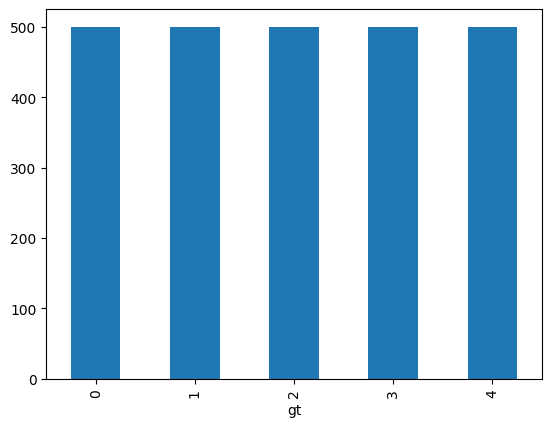

In [60]:
# i want to check an histogram of the target variable
df_2['gt'].value_counts().plot(kind='bar')

In [61]:
from itertools import combinations

unique_values = df_2['gt'].unique()
possible_combinations = list(combinations(unique_values, 3))

In [62]:
possible_combinations

[(0, 1, 2),
 (0, 1, 3),
 (0, 1, 4),
 (0, 2, 3),
 (0, 2, 4),
 (0, 3, 4),
 (1, 2, 3),
 (1, 2, 4),
 (1, 3, 4),
 (2, 3, 4)]

In [71]:
import pandas as pd
import numpy as np
from itertools import combinations


class Multi_SVM_one_vs_rest(SVM_2):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.models = {}
        self.classes = None
        self.binary_model = None


    def fit(self, X, y):
        classes = np.unique(y)
        if len(classes) < 2 or len(classes) > 3:
            raise(ValueError("Please select 2 or 3 classes"))
        
        self.classes = classes
        if len(classes) == 2:
            self.binary_model = SVM_2(C=self.C, kernel=self.kernel_type, gamma=self.gamma, p=self.p, tol=self.tol)
            self.binary_model.fit_smo(X, y)
        else:        
            for cls in classes:
                # One-vs-rest: classe positiva vs tutte le altre
                y_bin = np.where(y == cls, 1, -1)
                model = SVM_2(C=self.C, kernel=self.kernel_type, gamma=self.gamma, p=self.p, tol=self.tol)
                model.fit_smo(X, y_bin)
                self.models[cls] = model
        return self

    def predict(self, X):
        if len(self.classes) == 2:
            return self.binary_model.predict(X)
        else:
            # Ottieni la decision_function per ogni modello
            scores = np.column_stack([self.models[cls].decision_function(X) for cls in self.classes])
            # Scegli la classe con il punteggio più alto
            idx = np.argmax(scores, axis=1)
            return np.array(self.classes)[idx]


results_multi_ovr = []

for comb in possible_combinations:
    print(f"Training on classes: {comb}")
    selected_classes = comb  
    df_temp = df_2[df_2['gt'].isin(selected_classes)]

    X = df_temp.drop('gt', axis=1).values
    y = df_temp['gt'].values

    # 3. Split e allenamento
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    multi_svm = Multi_SVM_one_vs_rest(C=1.0, kernel='Gaussian', gamma=0.5)
    multi_svm.fit(X_train, y_train)
    y_pred = multi_svm.predict(X_test)

    # Salva i dati e i risultati
    results_multi_ovr.append({
    'classes': comb,
    'X_train': X_train,
    'X_test': X_test,
    'y_train': y_train,
    'y_test': y_test,
    'y_pred': y_pred,
    'report': classification_report(y_test, y_pred, output_dict=True)  
    })


    # 4. Valutazione
    from sklearn.metrics import classification_report
    print(classification_report(y_test, y_pred))

    

Training on classes: (0, 1, 2)

--- Iteration 1, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 191

--- Iteration 2, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 65

--- Iteration 3, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 76

--- Iteration 4, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 70

--- Iteration 5, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 69

--- Iteration 6, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 70

--- Iteration 7, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 54

--- Iteration 8, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 48

--- Iteration 9, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 45

--- 

In [72]:
for i in range(len(results_multi_ovr)):
    res = results_multi_ovr[i]
    print("Classi:", res['classes'])
    print("Accuracy:", res['report']['accuracy'])

Classi: (0, 1, 2)
Accuracy: 0.7833333333333333
Classi: (0, 1, 3)
Accuracy: 0.77
Classi: (0, 1, 4)
Accuracy: 0.7466666666666667
Classi: (0, 2, 3)
Accuracy: 0.7566666666666667
Classi: (0, 2, 4)
Accuracy: 0.6133333333333333
Classi: (0, 3, 4)
Accuracy: 0.5833333333333334
Classi: (1, 2, 3)
Accuracy: 0.7833333333333333
Classi: (1, 2, 4)
Accuracy: 0.7433333333333333
Classi: (1, 3, 4)
Accuracy: 0.7466666666666667
Classi: (2, 3, 4)
Accuracy: 0.7566666666666667


In [68]:
for i in range(len(results_multi_ovr)):
    res = results_multi_ovr[i]
    print("Classi:", res['classes'])
    print("Accuracy:", res['report']['accuracy'])


Classi: (0, 1, 2)
Accuracy: 0.8766666666666667
Classi: (0, 1, 3)
Accuracy: 0.8366666666666667
Classi: (0, 1, 4)
Accuracy: 0.78
Classi: (0, 2, 3)
Accuracy: 0.8633333333333333
Classi: (0, 2, 4)
Accuracy: 0.8
Classi: (0, 3, 4)
Accuracy: 0.7266666666666667
Classi: (1, 2, 3)
Accuracy: 0.89
Classi: (1, 2, 4)
Accuracy: 0.8766666666666667
Classi: (1, 3, 4)
Accuracy: 0.7966666666666666
Classi: (2, 3, 4)
Accuracy: 0.7633333333333333


In [ ]:
from itertools import combinations

class Multi_SVM_one_vs_one:
    def __init__(self, C=1.0, kernel='Gaussian', gamma=1, p=3, tol=1e-6):
        self.C = C
        self.kernel = kernel
        self.gamma = gamma
        self.p = p
        self.tol = tol
        self.models = []
        self.pair_classes = []

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.models = []
        self.pair_classes = []
        for cls1, cls2 in combinations(self.classes_, 2):
            idx = np.where((y == cls1) | (y == cls2))[0]
            X_pair = X[idx]
            y_pair = y[idx]
            y_bin = np.where(y_pair == cls1, 1, -1)
            model = SVM_2(C=self.C, kernel=self.kernel, gamma=self.gamma, p=self.p, tol=self.tol)
            model.fit(X_pair, y_bin)
            self.models.append(model)
            self.pair_classes.append((cls1, cls2))
        return self

    def predict(self, X):
        votes = np.zeros((X.shape[0], len(self.classes_)), dtype=int)
        for model, (cls1, cls2) in zip(self.models, self.pair_classes):
            pred = model.predict(X)
            for i, p in enumerate(pred):
                if p == 1:
                    votes[i, np.where(self.classes_ == cls1)[0][0]] += 1
                else:
                    votes[i, np.where(self.classes_ == cls2)[0][0]] += 1
        return self.classes_[np.argmax(votes, axis=1)]
    

for comb in possible_combinations:
    print(f"Training on classes: {comb}")
    selected_classes = comb  
    df_temp = df_2[df_2['gt'].isin(selected_classes)]

    X = df_temp.drop('gt', axis=1).values
    y = df_temp['gt'].values

    # 3. Split e allenamento
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    multi_svm = Multi_SVM_one_vs_rest(C=1.0, kernel='Gaussian', gamma=0.5)
    multi_svm.fit(X_train, y_train)
    y_pred = multi_svm.predict(X_test)

    # Salva i dati e i risultati
    results_multi_ovr.append({
    'classes': comb,
    'X_train': X_train,
    'X_test': X_test,
    'y_train': y_train,
    'y_test': y_test,
    'y_pred': y_pred,
    'report': classification_report(y_test, y_pred, output_dict=True)  
    })


    # 4. Valutazione
    from sklearn.metrics import classification_report
    print(classification_report(y_test, y_pred))


     pcost       dcost       gap    pres   dres
 0: -1.3413e+02 -1.7470e+03  8e+03  2e+00  8e-16
 1: -9.9682e+01 -1.0344e+03  9e+02  5e-03  6e-16
 2: -1.2983e+02 -2.5363e+02  1e+02  6e-04  6e-16
 3: -1.4174e+02 -1.6835e+02  3e+01  8e-05  4e-16
 4: -1.4501e+02 -1.5044e+02  5e+00  8e-06  3e-16
 5: -1.4579e+02 -1.4720e+02  1e+00  1e-06  3e-16
 6: -1.4599e+02 -1.4651e+02  5e-01  4e-15  3e-16
 7: -1.4607e+02 -1.4616e+02  9e-02  1e-14  3e-16
 8: -1.4608e+02 -1.4610e+02  1e-02  1e-14  2e-16
 9: -1.4609e+02 -1.4609e+02  4e-04  1e-14  3e-16
10: -1.4609e+02 -1.4609e+02  8e-06  8e-15  3e-16
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0: -1.3023e+02 -1.5061e+03  6e+03  2e+00  8e-16
 1: -1.0533e+02 -8.3918e+02  7e+02  3e-03  5e-16
 2: -1.3302e+02 -2.2767e+02  9e+01  4e-04  6e-16
 3: -1.4325e+02 -1.6602e+02  2e+01  7e-05  3e-16
 4: -1.4622e+02 -1.5126e+02  5e+00  1e-05  2e-16
 5: -1.4701e+02 -1.4817e+02  1e+00  1e-06  2e-16
 6: -1.4722e+02 -1.4746e+02  2e-01  2e-14  3e-1